In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,'../g3code/')
from survey_volume import comoving_volume
from g3misc import *

In [4]:
eco_mocks=[]
cc=3e5
zmax = 7000/3e5
zmin = 3000/3e5

for ii in range(8):
    mk = pd.read_csv(f'/Users/zhutchens/Documents/Research/ECO-halobiasmocks/ECO_cat_{ii}_Planck_memb_cat.csv')
    mk = mk[mk.M_r <= -17.33]
    mk.loc[:,'z'] = mk.loc[:,'cz'] / 3e5
    zmax = 7000 / 3e5 
    zmin = 3000 / 3e5 
    mk = mk[(mk.cz > cc*zmin) & (mk.cz < cc*zmax)]
    eco_mocks.append(mk)

In [9]:
nbins = np.arange(0.5,100.5,1)

In [10]:
halo_nN = []
for em in eco_mocks:
    halo_nN.append(np.histogram(multiplicity_function(em.haloid,False),bins=nbins)[0])

In [11]:
groups_nN = []
for em in eco_mocks:
    groups_nN.append(np.histogram(multiplicity_function(em.g3grp_l,False),bins=nbins)[0])

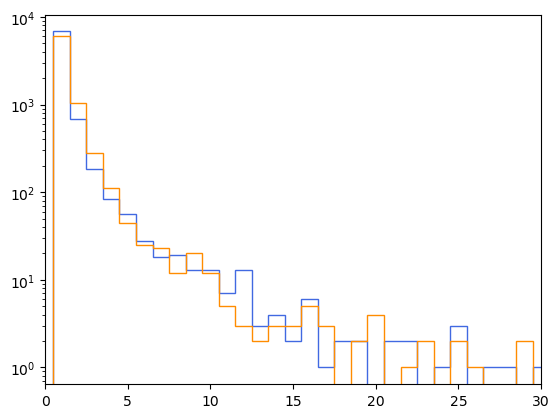

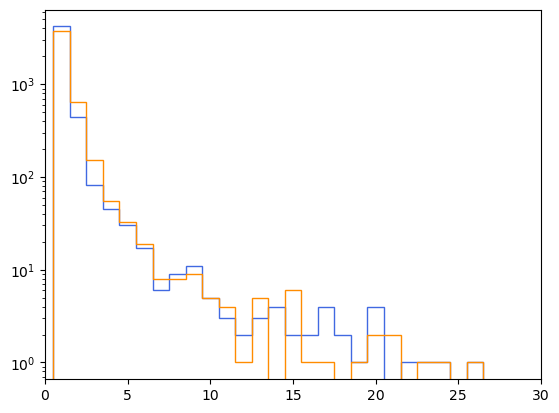

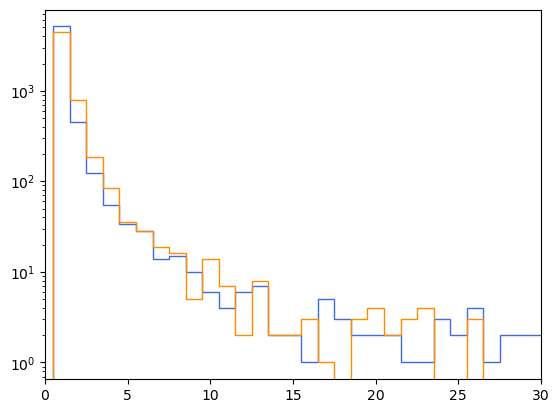

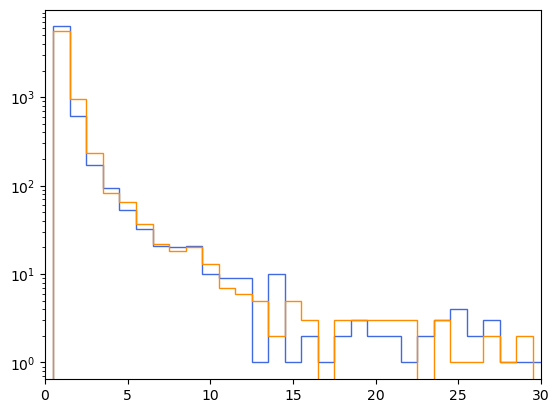

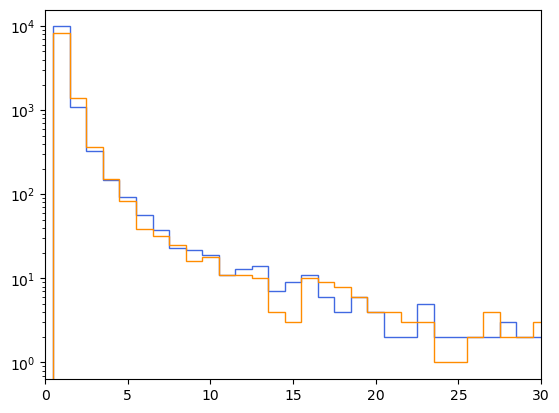

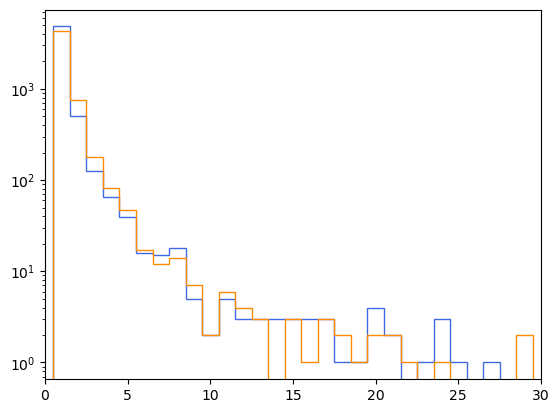

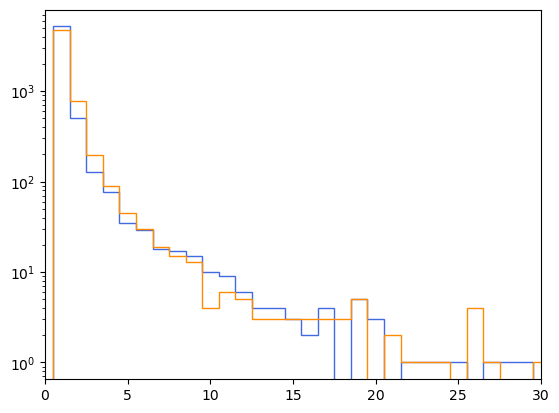

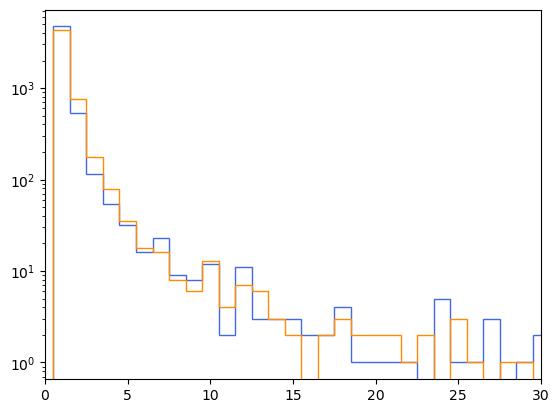

In [13]:
for i in range(8):
    plt.figure()
    plt.stairs(groups_nN[i], nbins, color='royalblue')
    plt.stairs(halo_nN[i], nbins, color='darkorange')
    plt.xlim(0,30)
    plt.yscale('log')
    plt.show()

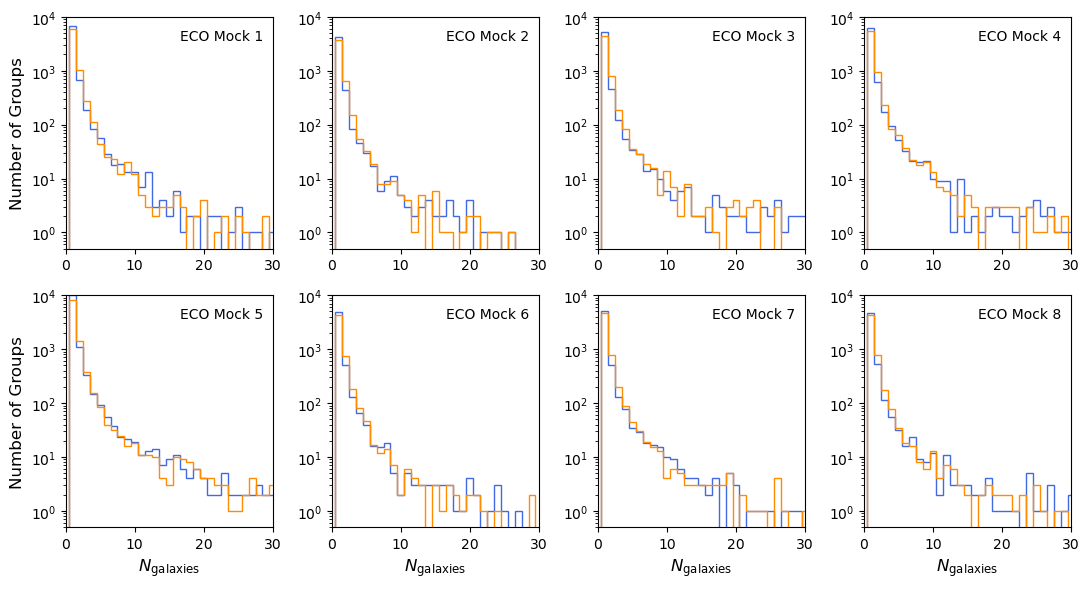

In [36]:
fig, axs = plt.subplot_mosaic('''ABCD\nEFGH''',figsize=(11,6))
keys='ABCDEFGH'
for i in range(8):
    axs[keys[i]].stairs(groups_nN[i], nbins, color='royalblue')
    axs[keys[i]].stairs(halo_nN[i], nbins, color='darkorange')
    axs[keys[i]].set_xlim(0,30)
    axs[keys[i]].set_yscale('log')
    axs[keys[i]].set_ylim(0.5,1e4)
    axs[keys[i]].annotate(xy=(0.55,0.9), xycoords='axes fraction', text=f'ECO Mock {i+1}')
#axs['A'].legend(loc='upper right')
for k in keys[4:]:
    axs[k].set_xlabel(r"$N_{\rm galaxies}$",fontsize=12)
for k in ['A','E']:
    axs[k].set_ylabel(r'Number of Groups',fontsize=12)
plt.tight_layout()
plt.savefig("../figures/ECO-mock-g3-multf.png",dpi=300)
plt.show()

In [23]:
keys[:4]

'ABCD'